In [1]:
from IPython.display import Image

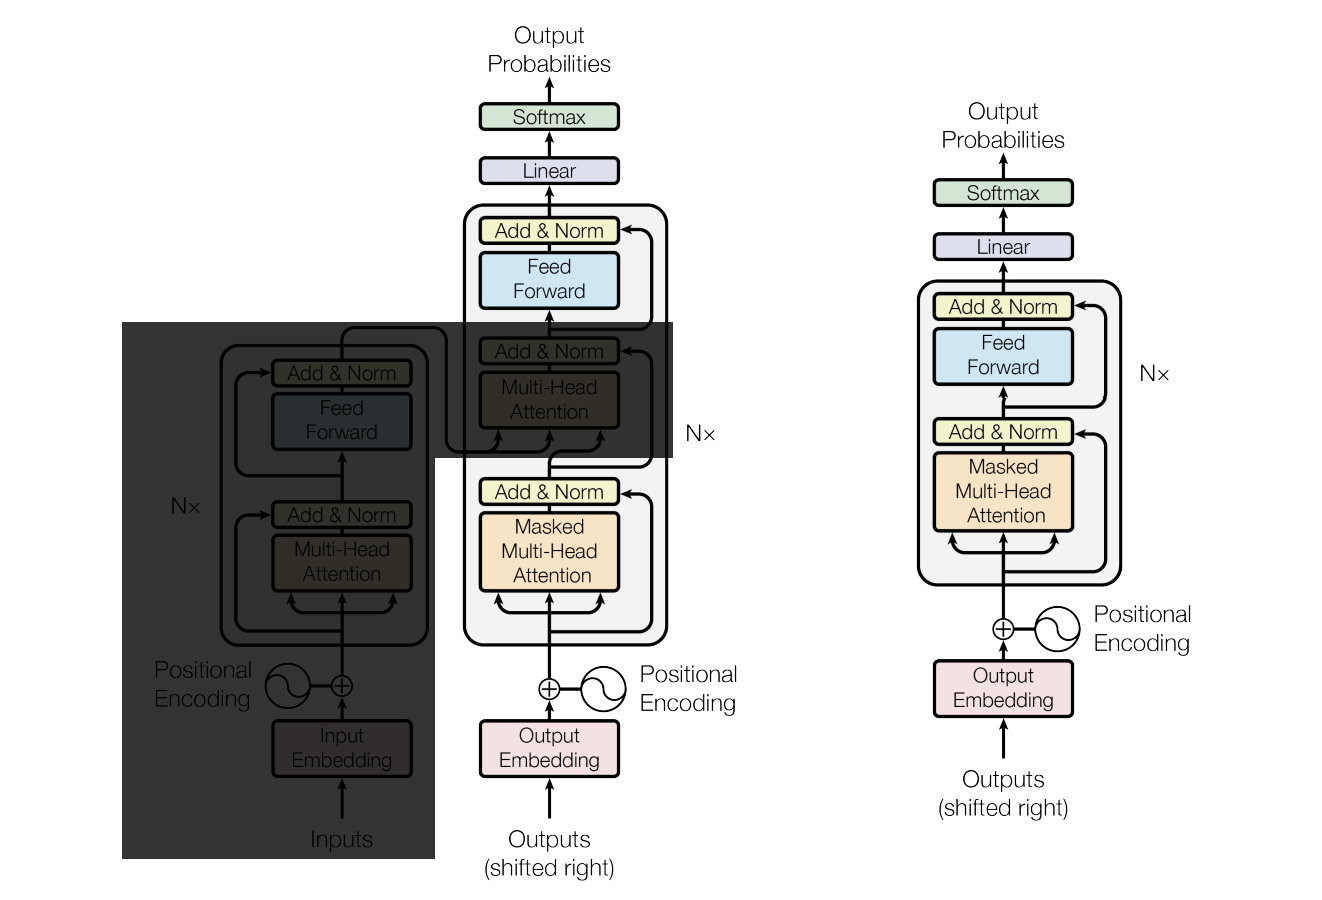

In [3]:
Image("/content/Decoder-onlu.png", width=500)

In [ ]:
vocab = [1st, 2nd, 3rd....]

##Output of Decoder :
1st  --> prob
2nd  --> prob
3rd  --> prob
...

## Token with max probability will be cosen as next token.

In [ ]:
input to decoder Model : Once upon a time


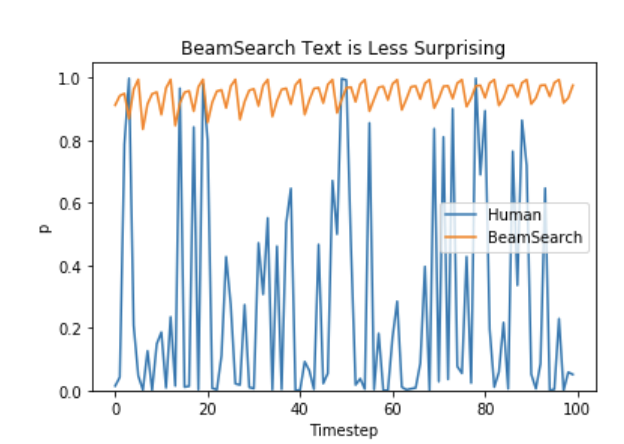

In [5]:
Image("/content/beam_vs_human.png", width=500)

###Decoding Strategies :

In [7]:
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM

In [8]:
model_name = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [9]:
prompt = "once upon a time"

input_ids = tokenizer(prompt, return_tensors="pt")

gen_tokens = model.generate(**input_ids)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In [10]:
gen_tokens

tensor([[27078,  2402,   257,   640,    11,   290,   314,  1101,   407,  1654,
           611,   340,   338,   257, 21083,   393,   407,    13,   198,   198,
            40,  1101,   407,  1654]])

In [11]:
tokenizer.decode(gen_tokens)

["once upon a time, and I'm not sure if it's a coincidence or not.\n\nI'm not sure"]

####max_new_tokens :

In [ ]:
# max_new_tokens :to contro length of generation

In [13]:
gen_tokens = model.generate(**input_ids,
                            max_new_tokens=100)

tokenizer.decode(gen_tokens)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


["once upon a time, and I'm not sure if it's a coincidence or not.\n\nI'm not sure if it's a coincidence or not. I'm not sure if it's a coincidence or not. I'm not sure if it's a coincidence or not. I'm not sure if it's a coincidence or not. I'm not sure if it's a coincidence or not. I'm not sure if it's a coincidence or not. I'm not sure if it's a coincidence or not."]

####no_repeat_ngram_size :

In [ ]:
# no_repeat_ngram_size : to avoide repetition of words (n-words)

In [ ]:
#  I'm not sure if it's a coincidence or not

In [15]:
gen_tokens = model.generate(**input_ids,
                            max_new_tokens=100,
                            no_repeat_ngram_size=2
                            )

tokenizer.decode(gen_tokens)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


["once upon a time, and I'm not sure if it's a coincidence or not.\n\nI'm sure you're all aware of the fact that I've been working on this project for a while now. I have a lot of work to do, but I want to make sure that it is as good as it can be. So, I'll be working with you guys on the next project. It's going to be a bit of a long project, so I hope you all enjoy it.<|endoftext|>"]

###Greedy Search :

In [ ]:
# Greedy Search : Token with max probability will be cosen as next token.

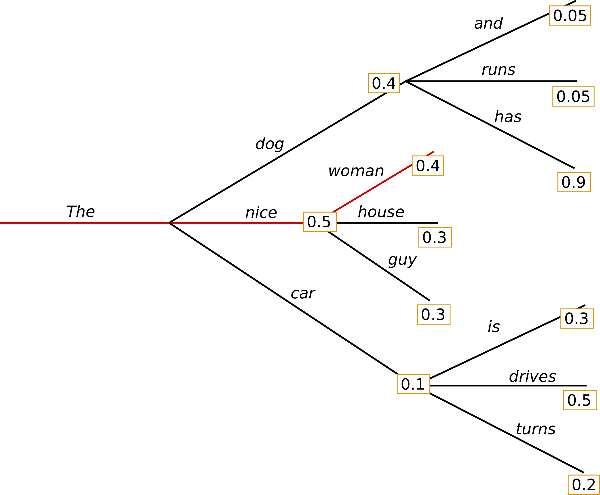

In [17]:
Image("/content/greedy_search.png", width=300)

In [18]:
# The --> nice woman
0.5 * 0.4

0.2

In [19]:
# The --> dog has
0.4 * 0.9

0.36000000000000004

###Beam Search :

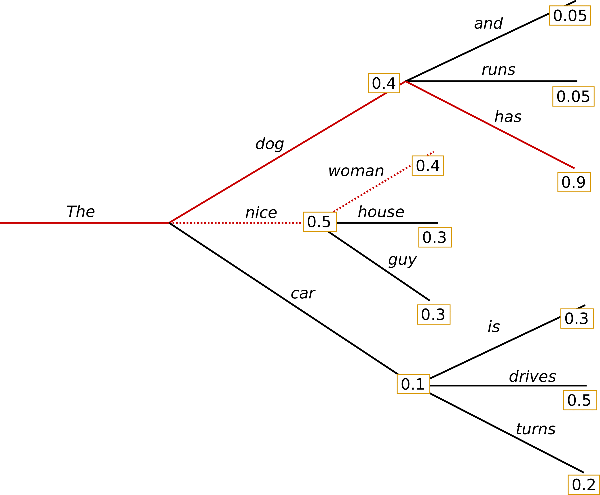

In [20]:
Image("/content/beam_search.png", width=300)

In [21]:
gen_tokens = model.generate(**input_ids,
                            num_beams=2

                            )

tokenizer.decode(gen_tokens)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


['once upon a time when the world was in a state of chaos.\n\n"I think it\'s important that we']

###Sampling :

In [ ]:
## Instaed of choosing max prob token as next token


In [25]:
gen_tokens = model.generate(**input_ids,
                            max_new_tokens=100,
                            do_sample=True,
                            # top_k=0

                            )

tokenizer.decode(gen_tokens)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


['once upon a time he has already taken advantage of the fact that, after the second day of the new term, there were more than four thousand of them, the most powerful men of the new government and the most powerful men of the old. But this very important fact did not exist until in January (March), at least five months. The whole body of government in the North America, and in the South America, were so divided and so weakened in this crisis, that the public could not think of themselves as being']

###Top-K Sampling :

In [ ]:
Select top "K" tokens with max prob,
and then choose one of them randomly as next token.

In [ ]:
## The
dog --> 0.4
nice --> 0.5
car  --> 0.1

In [28]:
prompt = "Once upon a time"

input_ids = tokenizer(prompt, return_tensors="pt")

gen_tokens = model.generate(**input_ids,
                            # max_new_tokens=100
                            )

tokenizer.decode(gen_tokens)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


['Once upon a time, the world was a place of great beauty and great danger. The world was a place of great']

In [31]:
prompt = "Once upon a time"

input_ids = tokenizer(prompt, return_tensors="pt")

gen_tokens = model.generate(**input_ids,
                            # max_new_tokens=100
                            do_sample=True,
                            top_k=5
                            )

tokenizer.decode(gen_tokens)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


["Once upon a time, when the world is in chaos.\n\nI've seen a lot of people who are very"]

In [ ]:
["Once upon a time the world's largest corporation, the world's largest corporation, was the one that had been the source"]

['Once upon a time, I thought I would have the same problem with the new-age model. But I have to']

["Once upon a time, when the world is in chaos.\n\nI've seen a lot of people who are very"]


###Top-P (Nucleus Sampling) :

In [ ]:
# Instead of sampling from top k tokens
# sample from cumulative sum of probabilities.

In [34]:
gen_tokens = model.generate(**input_ids,
                            # max_new_tokens=100
                            do_sample=True,
                            top_p = 0.1
                            )

tokenizer.decode(gen_tokens)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


['Once upon a time, the world was a place of peace and harmony. But now, the world is a place of']

In [ ]:
## The
dog --> 0.2
nice --> 0.1
car  --> 0.1
cat  --> 0.3
bat  --> 0.25
ball --> 0.05

###Temperature :

In [ ]:
>> Minimum temperature value, model will become more deterministic.
>> Maximum temperature value, model will become more random (creative)

In [ ]:
# 0-2

In [38]:
gen_tokens = model.generate(**input_ids,
                            # max_new_tokens=100
                            do_sample=True,
                            # top_p = 0.1
                            temperature = 0.001
                            )

tokenizer.decode(gen_tokens)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


['Once upon a time, the world was a place of great beauty and great danger. The world was a place of great']

In [ ]:
['Once upon a time, the world was a place of great beauty and great danger. The world was a place of great']

['Once upon a time, the world was a place of great beauty and great danger. The world was a place of great']

['Once upon a time, the world was a place of great beauty and great danger. The world was a place of great']




In [41]:
gen_tokens = model.generate(**input_ids,
                            # max_new_tokens=100
                            do_sample=True,
                            # top_p = 0.1
                            temperature = 0.9
                            )

tokenizer.decode(gen_tokens)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


['Once upon a time when there was no news from this side of the Atlantic, a little girl called Jane came along,']

In [ ]:
['Once upon a time you looked at their faces you felt the faint tingle of their breath as though on painkillers.']


['Once upon a time, I was looking for one that made me look like this. As I went back, I found']


['Once upon a time when there was no news from this side of the Atlantic, a little girl called Jane came along,']



In [ ]:
## Working of temperature

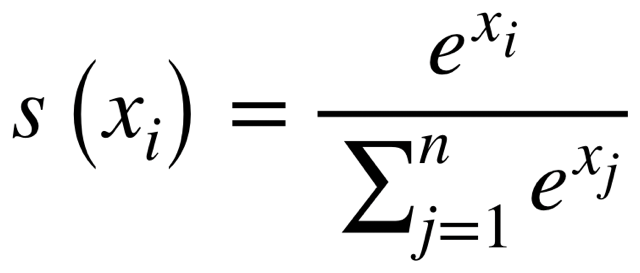

In [43]:
Image("/content/softmax_.png", width=500)

In [ ]:
## 3 classes
logits = [2.0, 1.0, 0.1]

# e**2.0 / e**2.0 + e**1.0  e**0.1

# e**1.0 / e**2.0 + e**1.0  e**0.1

# e**0.1 / e**2.0 + e**1.0  e**0.1

In [44]:
import numpy as np

In [52]:
logits = np.array([2.0, 1.0, 0.1])

probs = np.exp(logits) / np.sum(np.exp(logits))

probs

array([0.65900114, 0.24243297, 0.09856589])

In [48]:
def softmax(logits):
  return np.exp(logits) / np.sum(np.exp(logits))

In [49]:
softmax(logits)

array([0.65900114, 0.24243297, 0.09856589])

In [ ]:
# (e**2.0/temp )/( e**2.0 + e**1.0  e**0.1 / temp)

# e**1.0 / e**2.0 + e**1.0  e**0.1

# e**0.1 / e**2.0 + e**1.0  e**0.1

In [53]:
def softmax_with_temp(logits, temp):
  return np.exp(logits / temp) / np.sum(np.exp(logits / temp))

In [55]:
softmax_with_temp(logits, 0.01)

array([1.00000000e+00, 3.72007598e-44, 3.04823495e-83])

In [58]:
softmax_with_temp(logits, 1.8)

array([0.52035838, 0.2985574 , 0.18108422])